In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

# 讀取數據集
data = pd.read_csv("GDM_Model2.csv")

In [2]:
#數據分割
#將數據集分為訓練集和測試集
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [3]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3197 entries, 1575 to 3174
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        3197 non-null   int64  
 1   BMI                        3197 non-null   float64
 2   Gravida                    3197 non-null   int64  
 3   SystolicBloodPressureCuff  3197 non-null   int64  
 4   DiastolicBloodPressure     3197 non-null   int64  
 5   Glucoselevel0minblood      3197 non-null   float64
 6   GDM                        3197 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 199.8 KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 800 entries, 1760 to 2989
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        800 non-null    int64  
 1   BMI                        800 non-null    float64
 2 

0    2825
1     372
Name: GDM, dtype: int64


<AxesSubplot: xlabel='GDM', ylabel='count'>

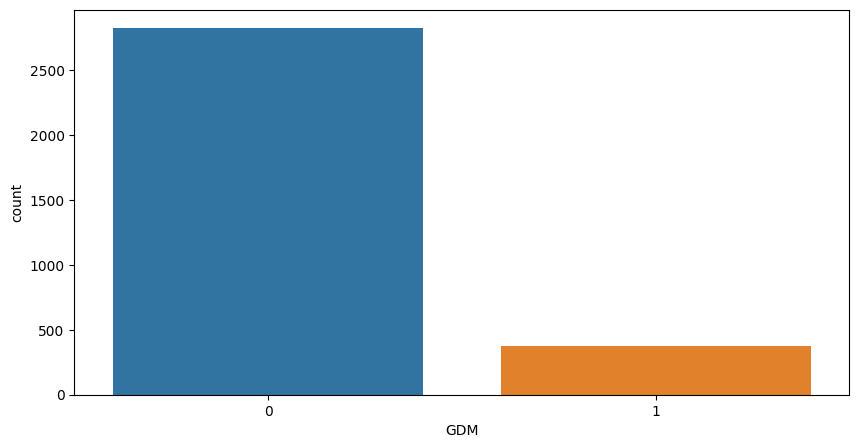

In [4]:
#Y/N個數
fig, ax =plt.subplots(figsize=(10,5))
print(train_data.GDM.value_counts())

sns.countplot(data=train_data,x='GDM',ax=ax)

0    709
1     91
Name: GDM, dtype: int64


<AxesSubplot: xlabel='GDM', ylabel='count'>

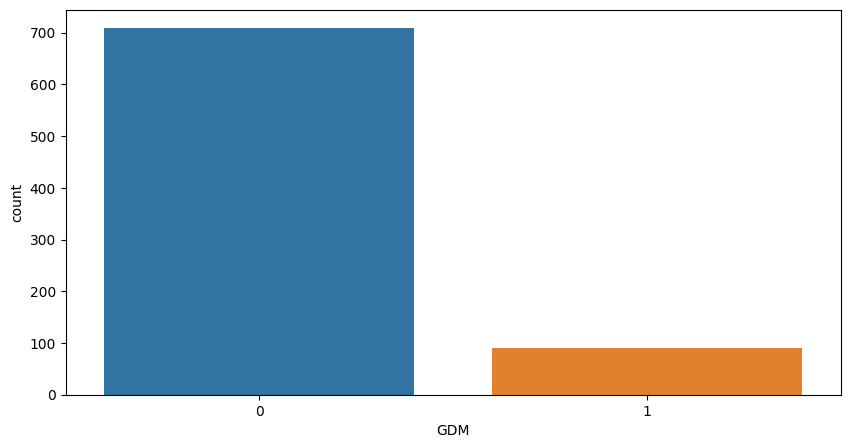

In [6]:
#Y/N個數
fig, ax =plt.subplots(figsize=(10,5))
print(test_data.GDM.value_counts())

sns.countplot(data=test_data,x='GDM',ax=ax)

In [7]:
#模型選擇
from pycaret.classification import *

#初始化PyCaret
#setup(data=train_data, target='GDM', session_id=42)
clf1 = setup(data=test_data, 
             target='GDM', 
             fold_shuffle=True, 
             session_id=2, 
             preprocess=False)

#排除模型
exclude_models = ['ridge','dummy']

#比較不同的分類器
best_model = compare_models()#exclude=exclude_models

,Description,Value
0,Session id,2
1,Target,GDM
2,Target type,Binary
3,Original data shape,"(800, 7)"
4,Transformed data shape,"(800, 7)"
5,Transformed train set shape,"(560, 7)"
6,Transformed test set shape,"(240, 7)"
7,Numeric features,6


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9589,0.7789,0.6381,1.0000,0.7736,0.7527,0.7785,0.4820
xgboost,Extreme Gradient Boosting,0.9571,0.8042,0.6381,0.9833,0.7672,0.7452,0.7698,0.4780
gbc,Gradient Boosting Classifier,0.9554,0.8334,0.6381,0.9583,0.7606,0.7373,0.7588,0.4380
lightgbm,Light Gradient Boosting Machine,0.9554,0.8064,0.6381,0.9583,0.7606,0.7373,0.7588,0.7060
et,Extra Trees Classifier,0.9536,0.7965,0.5929,1.0000,0.7358,0.7129,0.7464,0.5330
lr,Logistic Regression,0.9446,0.8594,0.5167,1.0000,0.6755,0.6492,0.6944,1.4190
ada,Ada Boost Classifier,0.9446,0.7866,0.6381,0.8743,0.7237,0.6941,0.7125,0.4090
qda,Quadratic Discriminant Analysis,0.9411,0.8482,0.5643,0.8967,0.6852,0.6548,0.6801,0.3530
lda,Linear Discriminant Analysis,0.9375,0.8638,0.4524,1.0000,0.6161,0.5881,0.6463,0.4110
nb,Naive Bayes,0.9321,0.8484,0.5500,0.8283,0.6497,0.6142,0.6360,0.3430


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [8]:
#模型訓練
#提取前5個及各分數最高的模型建立
rf = create_model('rf')
gbc = create_model('gbc')
lightgbm = create_model('lightgbm')
xgboost = create_model('xgboost')
lr = create_model('lr')
#lda = create_model('lda')
#et = create_model('et')
#ada = create_model('ada')
#ridge = create_model('ridge')
#dummy = create_model('dummy')
#knn = create_model('knn')
#qda = create_model('qda')
#nb = create_model('nb')
#dt = create_model('dt')
#svm = create_model('svm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,0.7367,0.6667,1.0000,0.8000,0.7812,0.8006
1,0.9464,0.7017,0.5000,1.0000,0.6667,0.6410,0.6868
2,0.9464,0.7167,0.5000,1.0000,0.6667,0.6410,0.6868
3,0.9643,0.8167,0.6667,1.0000,0.8000,0.7812,0.8006
4,0.9464,0.6950,0.5000,1.0000,0.6667,0.6410,0.6868
5,0.9821,0.9033,0.8333,1.0000,0.9091,0.8993,0.9039
6,0.9643,0.7711,0.7143,1.0000,0.8333,0.8140,0.8284
7,0.9464,0.8149,0.5714,1.0000,0.7273,0.7000,0.7338
8,0.9643,0.9009,0.7143,1.0000,0.8333,0.8140,0.8284


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,0.8533,0.6667,1.0000,0.8000,0.7812,0.8006
1,0.9464,0.6367,0.5000,1.0000,0.6667,0.6410,0.6868
2,0.9464,0.7867,0.5000,1.0000,0.6667,0.6410,0.6868
3,0.9643,0.9533,0.6667,1.0000,0.8000,0.7812,0.8006
4,0.9286,0.7600,0.5000,0.7500,0.6000,0.5625,0.5765
5,0.9821,0.8633,0.8333,1.0000,0.9091,0.8993,0.9039
6,0.9643,0.8571,0.7143,1.0000,0.8333,0.8140,0.8284
7,0.9464,0.8980,0.5714,1.0000,0.7273,0.7000,0.7338
8,0.9643,0.8834,0.7143,1.0000,0.8333,0.8140,0.8284


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,0.8233,0.6667,1.0000,0.8000,0.7812,0.8006
1,0.9464,0.6900,0.5000,1.0000,0.6667,0.6410,0.6868
2,0.9464,0.7000,0.5000,1.0000,0.6667,0.6410,0.6868
3,0.9643,0.8867,0.6667,1.0000,0.8000,0.7812,0.8006
4,0.9286,0.7167,0.5000,0.7500,0.6000,0.5625,0.5765
5,0.9821,0.8833,0.8333,1.0000,0.9091,0.8993,0.9039
6,0.9643,0.8192,0.7143,1.0000,0.8333,0.8140,0.8284
7,0.9464,0.7755,0.5714,1.0000,0.7273,0.7000,0.7338
8,0.9643,0.9096,0.7143,1.0000,0.8333,0.8140,0.8284


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,0.8567,0.6667,1.0000,0.8000,0.7812,0.8006
1,0.9464,0.6700,0.5000,1.0000,0.6667,0.6410,0.6868
2,0.9464,0.7200,0.5000,1.0000,0.6667,0.6410,0.6868
3,0.9643,0.9000,0.6667,1.0000,0.8000,0.7812,0.8006
4,0.9464,0.6767,0.5000,1.0000,0.6667,0.6410,0.6868
5,0.9821,0.8867,0.8333,1.0000,0.9091,0.8993,0.9039
6,0.9643,0.7901,0.7143,1.0000,0.8333,0.8140,0.8284
7,0.9464,0.7872,0.5714,1.0000,0.7273,0.7000,0.7338
8,0.9464,0.9096,0.7143,0.8333,0.7692,0.7391,0.7419


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,0.8733,0.6667,1.0000,0.8000,0.7812,0.8006
1,0.9286,0.7400,0.3333,1.0000,0.5000,0.4717,0.5556
2,0.9464,0.8600,0.5000,1.0000,0.6667,0.6410,0.6868
3,0.9464,0.8833,0.5000,1.0000,0.6667,0.6410,0.6868
4,0.9464,0.7800,0.5000,1.0000,0.6667,0.6410,0.6868
5,0.9643,0.8333,0.6667,1.0000,0.8000,0.7812,0.8006
6,0.9464,0.9184,0.5714,1.0000,0.7273,0.7000,0.7338
7,0.9286,0.8805,0.4286,1.0000,0.6000,0.5676,0.6295
8,0.9286,0.9417,0.4286,1.0000,0.6000,0.5676,0.6295


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [9]:
stacker = stack_models(estimator_list = [rf,gbc,lightgbm,xgboost,lr], meta_model = rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,0.7567,0.6667,1.0000,0.8000,0.7812,0.8006
1,0.9464,0.7667,0.5000,1.0000,0.6667,0.6410,0.6868
2,0.9464,0.7050,0.5000,1.0000,0.6667,0.6410,0.6868
3,0.9643,0.9583,0.6667,1.0000,0.8000,0.7812,0.8006
4,0.9464,0.7783,0.5000,1.0000,0.6667,0.6410,0.6868
5,0.9821,0.8983,0.8333,1.0000,0.9091,0.8993,0.9039
6,0.9643,0.7813,0.7143,1.0000,0.8333,0.8140,0.8284
7,0.9464,0.7638,0.5714,1.0000,0.7273,0.7000,0.7338
8,0.9643,0.8090,0.7143,1.0000,0.8333,0.8140,0.8284


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

In [8]:
stacker

StackingClassifier(cv=5,
                   estimators=[('Random Forest Classifier',
                                RandomForestClassifier(bootstrap=True,
                                                       ccp_alpha=0.0,
                                                       class_weight=None,
                                                       criterion='gini',
                                                       max_depth=None,
                                                       max_features='sqrt',
                                                       max_leaf_nodes=None,
                                                       max_samples=None,
                                                       min_impurity_decrease=0.0,
                                                       min_samples_leaf=1,
                                                       min_samples_split=2,
                                                       min_weight_fraction_leaf=0.0,
                                                       n_estimators=100,
                                                       n_jobs=-1,
                                                       oob_scor...
                                                          ccp_alpha=0.0,
                                                          class_weight=None,
                                                          criterion='gini',
                                                          max_depth=None,
                                                          max_features='sqrt',
                                                          max_leaf_nodes=None,
                                                          max_samples=None,
                                                          min_impurity_decrease=0.0,
                                                          min_samples_leaf=1,
                                                          min_samples_split=2,
                                                          min_weight_fraction_leaf=0.0,
                                                          n_estimators=100,
                                                          n_jobs=-1,
                                                          oob_score=False,
                                                          random_state=2,
                                                          verbose=0,
                                                          warm_start=False),
                   n_jobs=-1, passthrough=True, stack_method='auto', verbose=0)

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

...

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "D:\anaconda3\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "D:\anaconda3\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] 遠端主機已強制關閉一個現存的連線。
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>

In [9]:
stacker_model = tune_model(stacker)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9643,0.9133,0.6667,1.0000,0.8000,0.7812,0.8006
1,0.9464,0.7200,0.5000,1.0000,0.6667,0.6410,0.6868
2,0.9464,0.8167,0.5000,1.0000,0.6667,0.6410,0.6868
3,0.9643,0.9100,0.6667,1.0000,0.8000,0.7812,0.8006
4,0.9464,0.7033,0.5000,1.0000,0.6667,0.6410,0.6868
5,0.9821,0.8600,0.8333,1.0000,0.9091,0.8993,0.9039
6,0.9643,0.9125,0.7143,1.0000,0.8333,0.8140,0.8284
7,0.9464,0.8717,0.5714,1.0000,0.7273,0.7000,0.7338
8,0.9643,0.8892,0.7143,1.0000,0.8333,0.8140,0.8284


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [10]:
stacker_model

StackingClassifier(cv=5,
                   estimators=[('Random Forest Classifier',
                                RandomForestClassifier(bootstrap=True,
                                                       ccp_alpha=0.0,
                                                       class_weight=None,
                                                       criterion='gini',
                                                       max_depth=None,
                                                       max_features='sqrt',
                                                       max_leaf_nodes=None,
                                                       max_samples=None,
                                                       min_impurity_decrease=0.0,
                                                       min_samples_leaf=1,
                                                       min_samples_split=2,
                                                       min_weight_fraction_leaf=0.0,
                                                       n_estimators=100,
                                                       n_jobs=-1,
                                                       oob_scor...
                                                          ccp_alpha=0.0,
                                                          class_weight=None,
                                                          criterion='gini',
                                                          max_depth=None,
                                                          max_features='sqrt',
                                                          max_leaf_nodes=None,
                                                          max_samples=None,
                                                          min_impurity_decrease=0.0,
                                                          min_samples_leaf=1,
                                                          min_samples_split=2,
                                                          min_weight_fraction_leaf=0.0,
                                                          n_estimators=100,
                                                          n_jobs=-1,
                                                          oob_score=False,
                                                          random_state=2,
                                                          verbose=0,
                                                          warm_start=False),
                   n_jobs=-1, passthrough=True, stack_method='auto', verbose=0)

In [33]:
save_model(stacker_model,'stacker_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=FastMemory(location=C:\Users\User\AppData\Local\Temp\joblib),
          steps=[('placeholder', None),
                 ('trained_model',
                  StackingClassifier(cv=5,
                                     estimators=[('Random Forest Classifier',
                                                  RandomForestClassifier(bootstrap=True,
                                                                         ccp_alpha=0.0,
                                                                         class_weight=None,
                                                                         criterion='gini',
                                                                         max_depth=None,
                                                                         max_features='sqrt',
                                                                         max_leaf_nodes=None,
                                                                         max_samples=Non

In [34]:
#进進行預測
model = load_model('stacker_model')
pred = predict_model(model,data = test_data)
pred2 = predict_model(rf,data = test_data)

pred.head()
pred2.head()

Transformation Pipeline and Model Successfully Loaded


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.9862,0.9580,0.8791,1.0000,0.9357,0.9280,0.9304


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9875,0.9721,0.8901,1.0000,0.9419,0.9349,0.9369


,Age,Weight,Height,BMI,Gravida,SystolicBloodPressureCuff,DiastolicBloodPressure,Glucoselevel0minblood,GDM,prediction_label,prediction_score
1760,42,58.009998,166.0,21.049999,2,113,67,4.1,0,0,0.98
3016,30,61.000000,153.5,25.889999,2,97,75,4.2,0,0,0.99
1770,29,81.809998,163.0,30.790001,1,120,67,3.9,0,0,1.00
3703,43,78.000000,153.0,33.320000,1,140,82,5.7,1,1,0.95
2099,29,83.989998,160.0,32.810001,7,90,70,4.6,0,0,0.93


In [13]:
from sklearn.metrics import accuracy_score
accuracy_score(pred['GDM'],pred['prediction_label'])


0.98625

In [14]:
accuracy_score(pred2['GDM'],pred2['prediction_label'])

0.9875

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

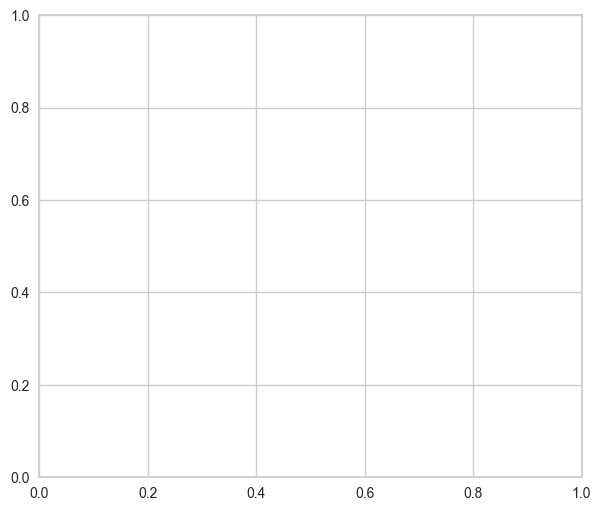

In [15]:
# 評估調整後的模型
evaluate_model(model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

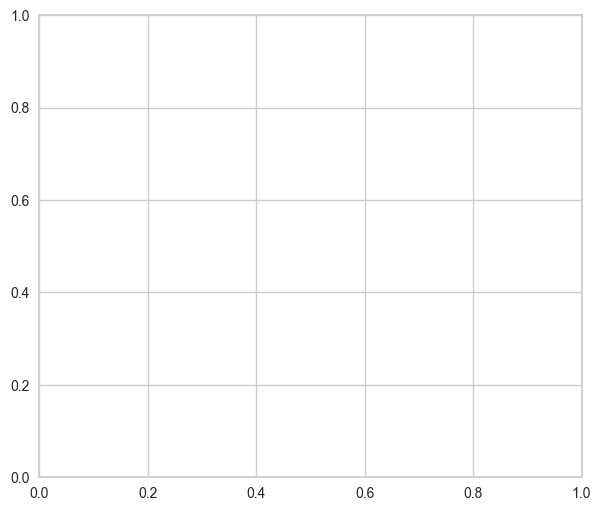

In [16]:
evaluate_model(rf)

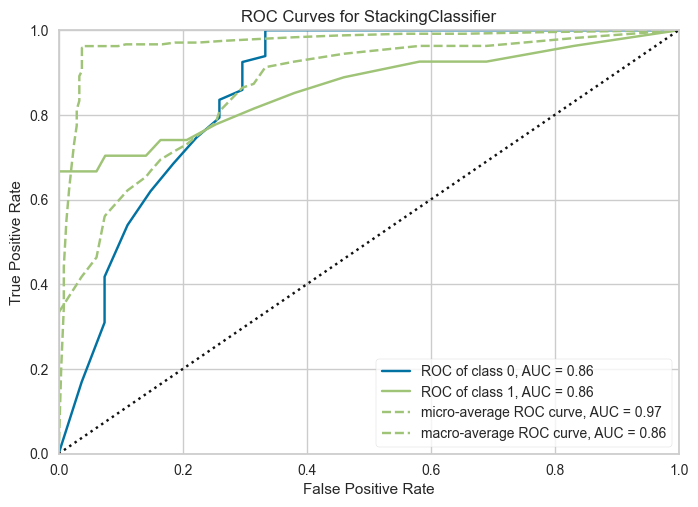

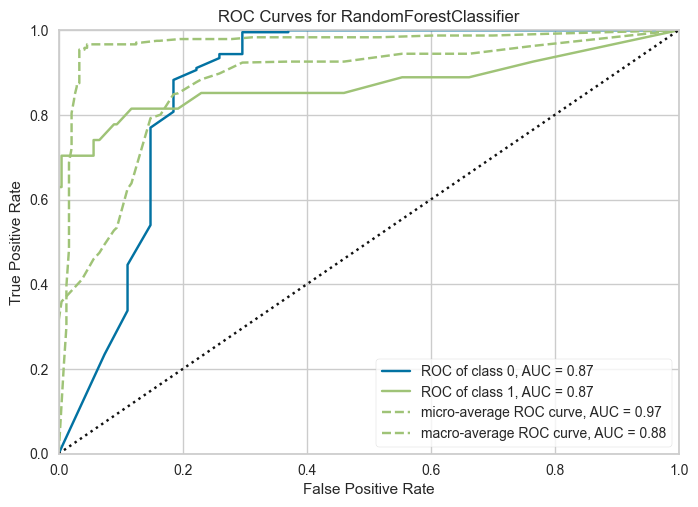

In [19]:
plot_model(stacker_model, plot='auc' )
plot_model(rf, plot='auc' )

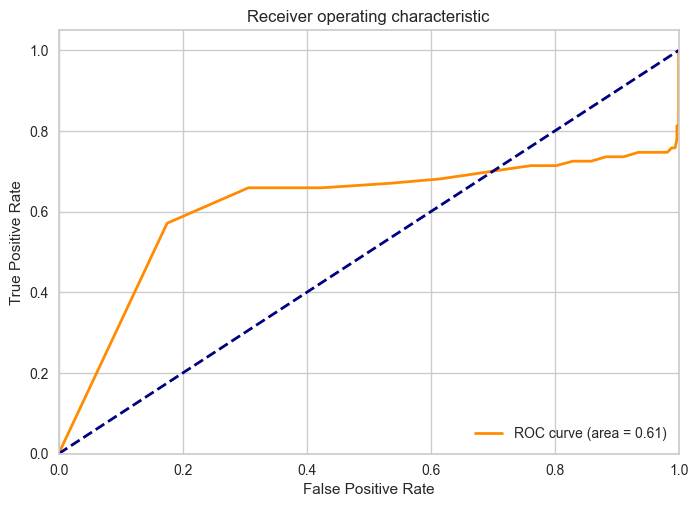

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 假設模型對測試集的預測結果存儲在y_score中，真實標籤存儲在y_true中
fpr, tpr, thresholds = roc_curve(pred['GDM'], pred['prediction_score'])
roc_auc = auc(fpr, tpr)

# 繪製ROC曲線
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [15]:
# Step 6: 模型集成
# 使用Bagging集成多個最優分類器
#ensemble_model = ensemble_model(model, method='Bagging')


In [16]:
# Step 7: 模型評估
from sklearn.metrics import classification_report, confusion_matrix

# 預測測試集數據
predictions = predict_model(model, data=test_data)

# 計算混淆矩陣和分類報告
cm = confusion_matrix(predictions['GDM'], predictions['prediction_label'])
report = classification_report(predictions['GDM'], predictions['prediction_label'])

# 輸出混淆矩陣和分類報告
print("Confusion matrix:")
print(cm)
print("Classification report:")
print(report)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.8888,0.6524,0.0220,1.0000,0.0430,0.0383,0.1397


Confusion matrix:
[[709   0]
 [ 89   2]]
Classification report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       709
           1       1.00      0.02      0.04        91

    accuracy                           0.89       800
   macro avg       0.94      0.51      0.49       800
weighted avg       0.90      0.89      0.84       800



In [17]:
# Step 8: 模型解釋性分析
# 解釋模型中各個特徵的重要性
interpret_model(model)
#interpret_model(lr)

TypeError: This function only supports tree based models for binary classification: et, xgboost, lightgbm, dt, rf.

In [ ]:
# Step 9: 研究結果分析
# 繪製特徵重要性圖表
plot_model(model, plot='feature')


# 繪製錯誤分析圖表
plot_model(model, plot='error')

# 繪製分類器學習曲線和驗證曲線
plot_model(model, plot='learning')
plot_model

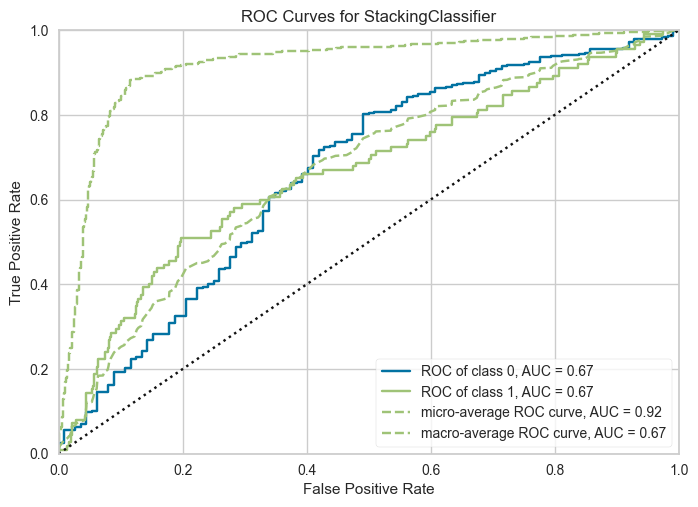

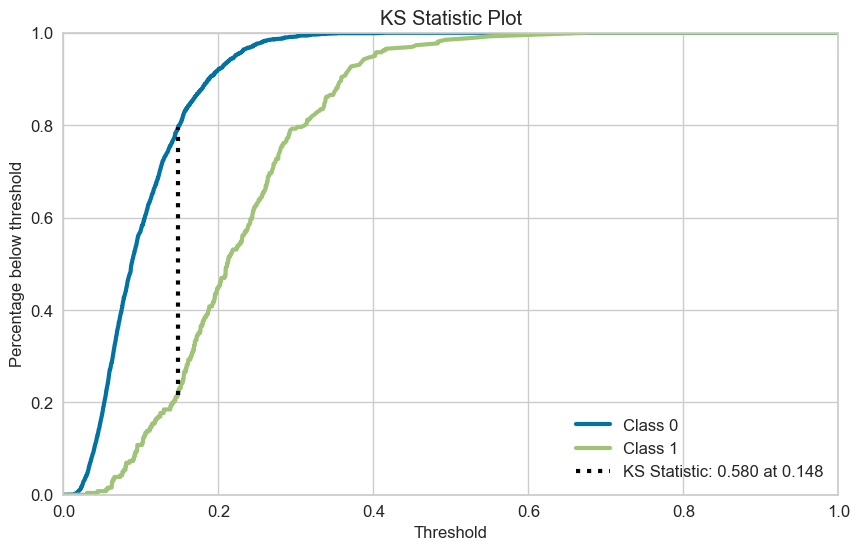

In [18]:
# 繪製ROC曲線和KS曲線
plot_model(model, plot='auc')
plot_model(model, plot='ks')
